In [1]:
import scipy
print(scipy.__version__)


1.15.3


In [2]:
import openpyxl
import matplotlib.pyplot as plt




In [3]:
import pandas as pd
import numpy as np

from SyntheticControlMethods import Synth, DiffSynth


In [4]:
data = pd.read_excel("fichier_nettoye2.xlsx")
data.head(10)

,Country Name,Time,Population growth (annual %) [SP.POP.GROW],Asylum-seekers by country or territory of origin [SM.POP.ASYS.EO],Access to electricity (% of population) [EG.ELC.ACCS.ZS],External balance on goods and services (% of GDP) [NE.RSB.GNFS.ZS],Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS],GDP per capita (constant 2015 US$),Trade (% of GDP) [NE.TRD.GNFS.ZS],Merchandise trade (% of GDP) [TG.VAL.TOTL.GD.ZS],"Birth rate, crude (per 1,000 people) [SP.DYN.CBRT.IN]","Death rate, crude (per 1,000 people) [SP.DYN.CDRT.IN]","Unemployment, total (% of total labor force) (modeled ILO estimate) [SL.UEM.TOTL.ZS]"
0,Algeria,2000,1.399669,2320,98.6,21.281092,42.069718,3553.324205,62.858344,56.947934,19.574,5.109,29.77
1,Algeria,2001,1.373291,2746,98.6,13.712814,34.121231,3610.006056,54.529649,48.933405,19.405,5.022,27.30
2,Algeria,2002,1.330395,2374,98.6,9.684723,33.137164,3754.660815,56.589605,50.016172,19.096,4.880,25.90
3,Algeria,2003,1.329615,1910,98.6,13.568992,35.669064,3945.898161,57.769135,48.369495,19.614,4.874,23.72
4,Algeria,2004,1.396440,1335,98.6,15.427921,38.392959,4066.282048,61.357998,53.825502,20.337,4.744,17.65
5,Algeria,2005,1.463309,1381,98.6,21.902106,44.371283,4223.602521,66.840460,61.990748,21.136,4.731,15.27
6,Algeria,2006,1.541274,1531,98.7,25.612977,45.764134,4279.615471,65.915292,61.802379,21.998,4.724,12.27
7,Algeria,2007,1.669072,1340,98.7,21.894838,44.720156,4339.250558,67.545473,61.617288,22.873,4.733,13.79
8,Algeria,2008,1.818853,1522,99.3,20.265871,45.647182,4367.565380,71.028492,65.846805,23.735,4.720,11.33
9,Algeria,2009,1.915885,1537,98.8,0.887258,32.586006,4336.100541,64.284755,56.193136,24.189,4.705,10.16


In [5]:
# Fit synthetic control
sc = Synth (data, "GDP per capita (constant 2015 US$)", "Country Name", "Time", 2011, "Libya", pen="auto", n_optim = 10, random_seed = 0 )

(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)


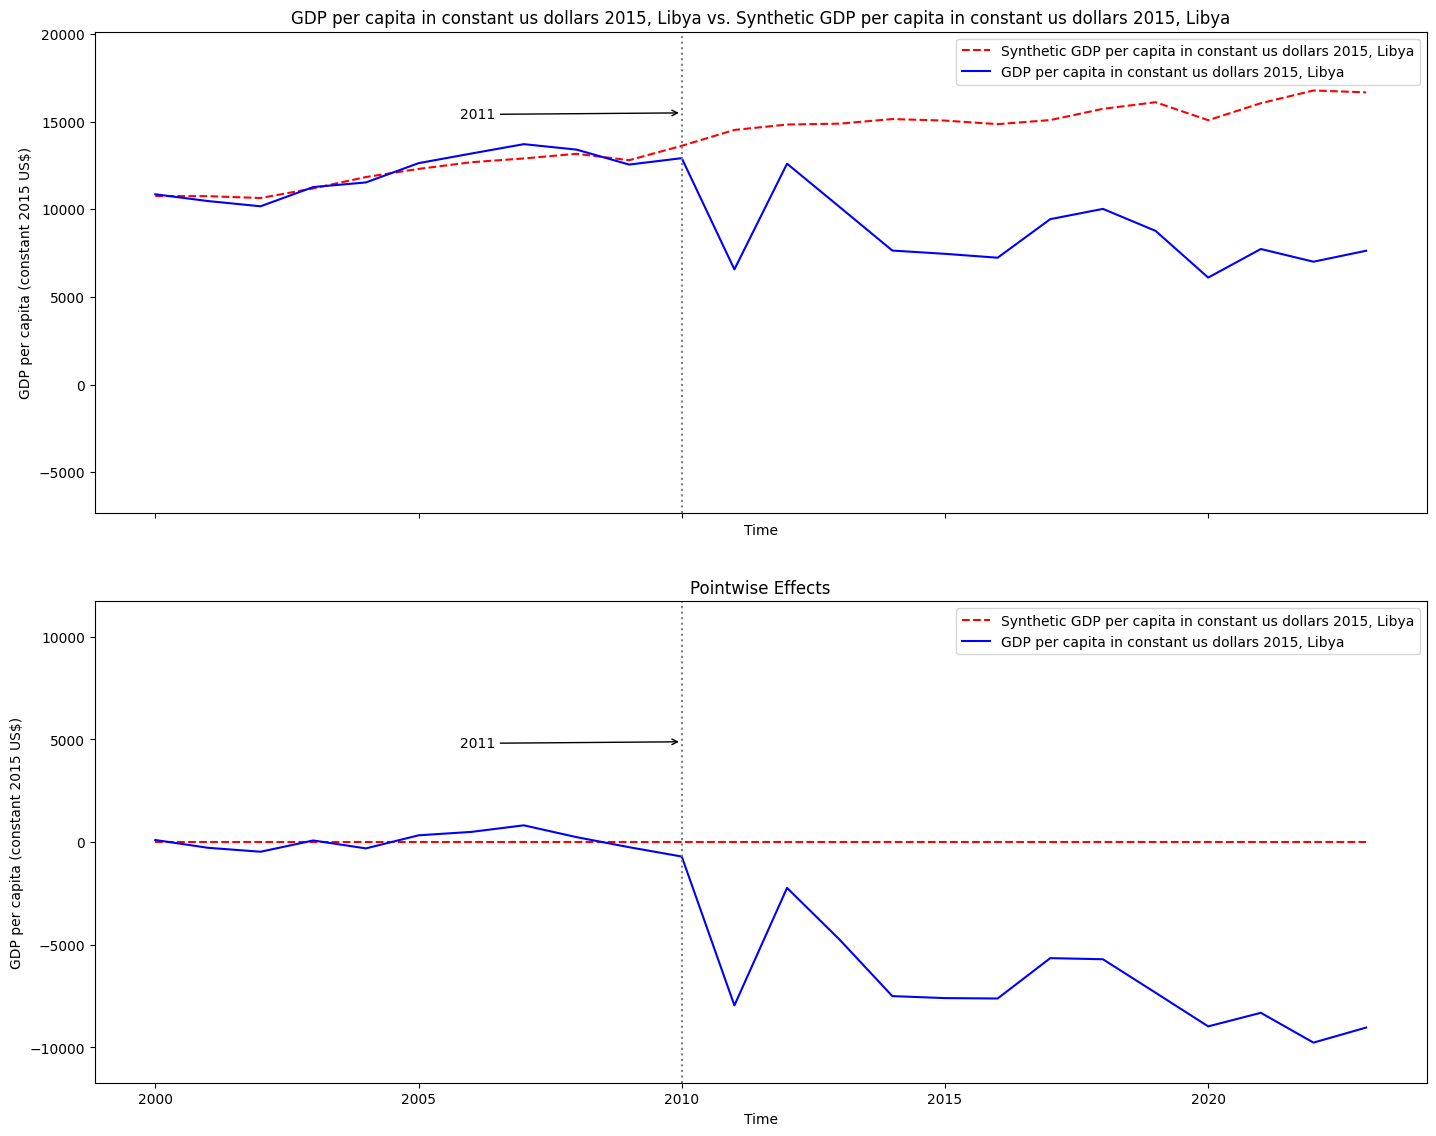

In [6]:
sc.plot(["original", "pointwise"], 
        treated_label="GDP per capita in constant us dollars 2015, Libya", 
        synth_label="Synthetic GDP per capita in constant us dollars 2015, Libya", 
        treatment_label="2011")

In [7]:
sc.original_data.weight_df

,Weight
Kazakhstan,0.649741
Saudi Arabia,0.343849


In [8]:

#Treated unit is always first unit in rmspe_df
sc.original_data.rmspe_df

,unit,pre_rmspe,post_rmspe,post/pre
0,Libya,431.102459,7379.707444,17.118222


In [9]:
sc.original_data.comparison_df

,Libya,Synthetic Libya,WMAPE,Importance
Population growth (annual %) [SP.POP.GROW],1.99,1.93,1.52,0.15
Asylum-seekers by country or territory of origin [SM.POP.ASYS.EO],693.27,485.16,229.56,0.15
Access to electricity (% of population) [EG.ELC.ACCS.ZS],90.27,99.92,9.66,0.06
External balance on goods and services (% of GDP) [NE.RSB.GNFS.ZS],28.98,12.96,16.07,0.18
Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS],57.87,50.10,7.82,0.20
GDP per capita (constant 2015 US$),12061.17,12057.37,6961.24,0.09
Trade (% of GDP) [NE.TRD.GNFS.ZS],86.76,87.24,5.67,0.02
Merchandise trade (% of GDP) [TG.VAL.TOTL.GD.ZS],57.47,70.43,12.96,0.09
"Birth rate, crude (per 1,000 people) [SP.DYN.CBRT.IN]",23.11,20.42,2.69,0.00
"Death rate, crude (per 1,000 people) [SP.DYN.CDRT.IN]",4.67,7.52,4.14,0.01


(11,)


C:\Users\leogr\Documents\Ensai 2A\Stage Université de Florence\Lybia and stuff\synth_env311\Lib\site-packages\cvxpy\problems\problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)


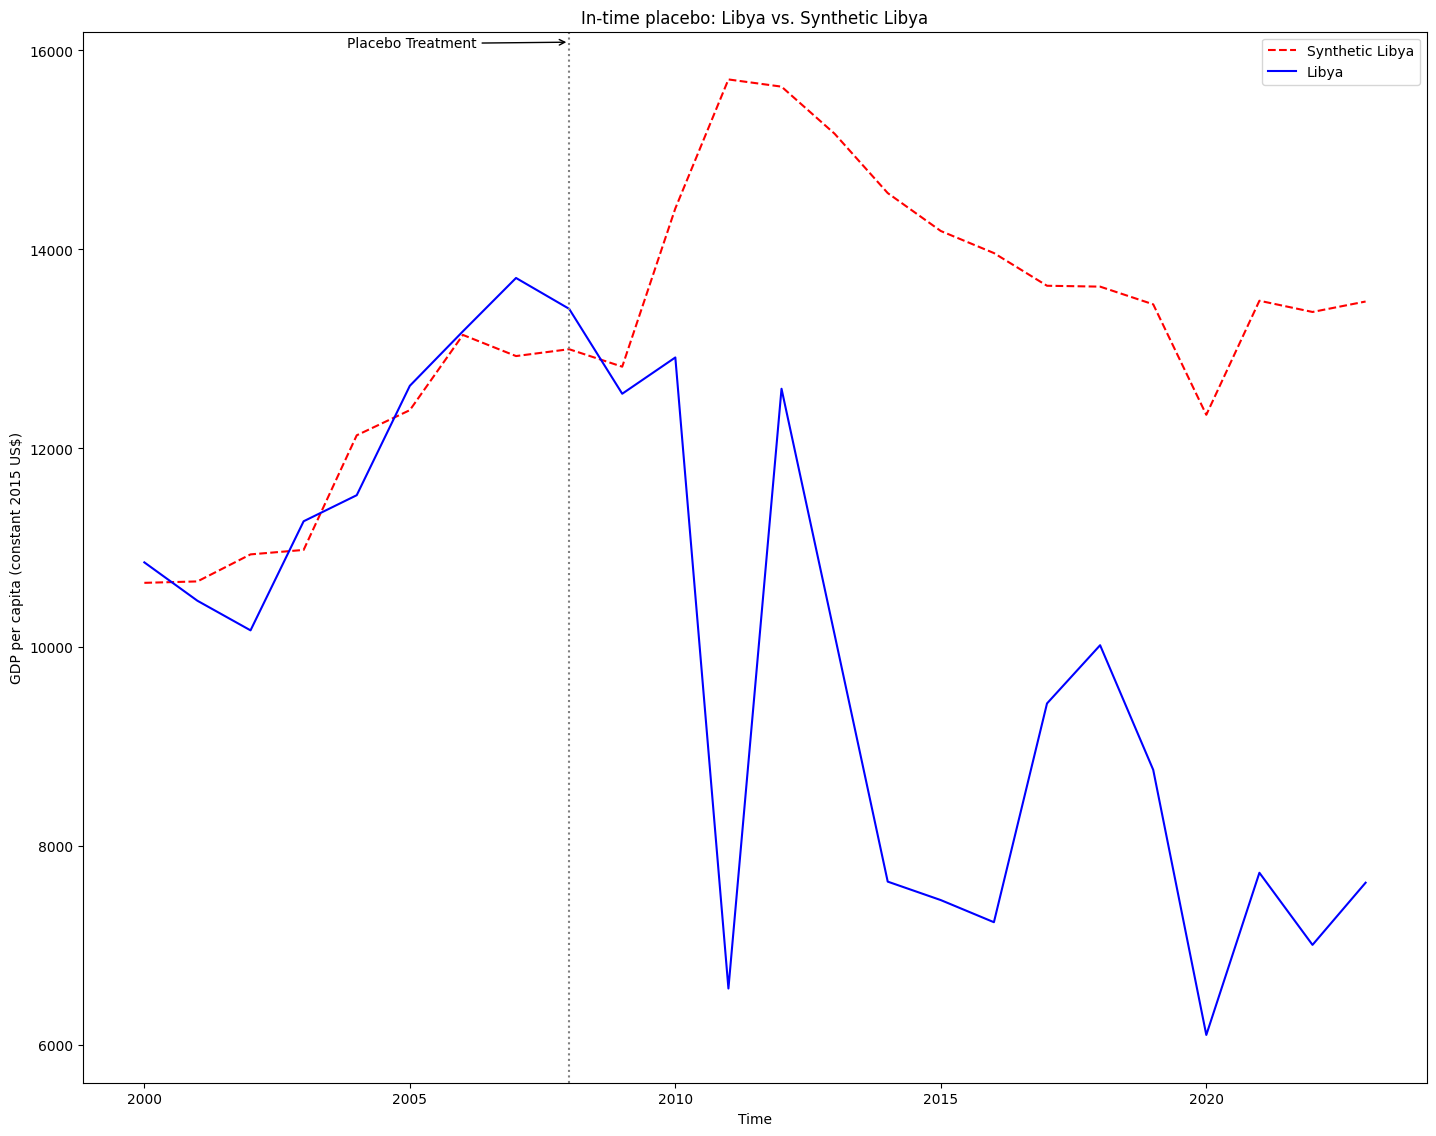

In [10]:
sc.in_time_placebo(2008, n_optim=10)

#Visualize
sc.plot(['in-time placebo'], 
            treated_label="Libya",
            synth_label="Synthetic Libya") # On confirme par le placebo temporel

In [11]:
sc.in_space_placebo(1)

(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)


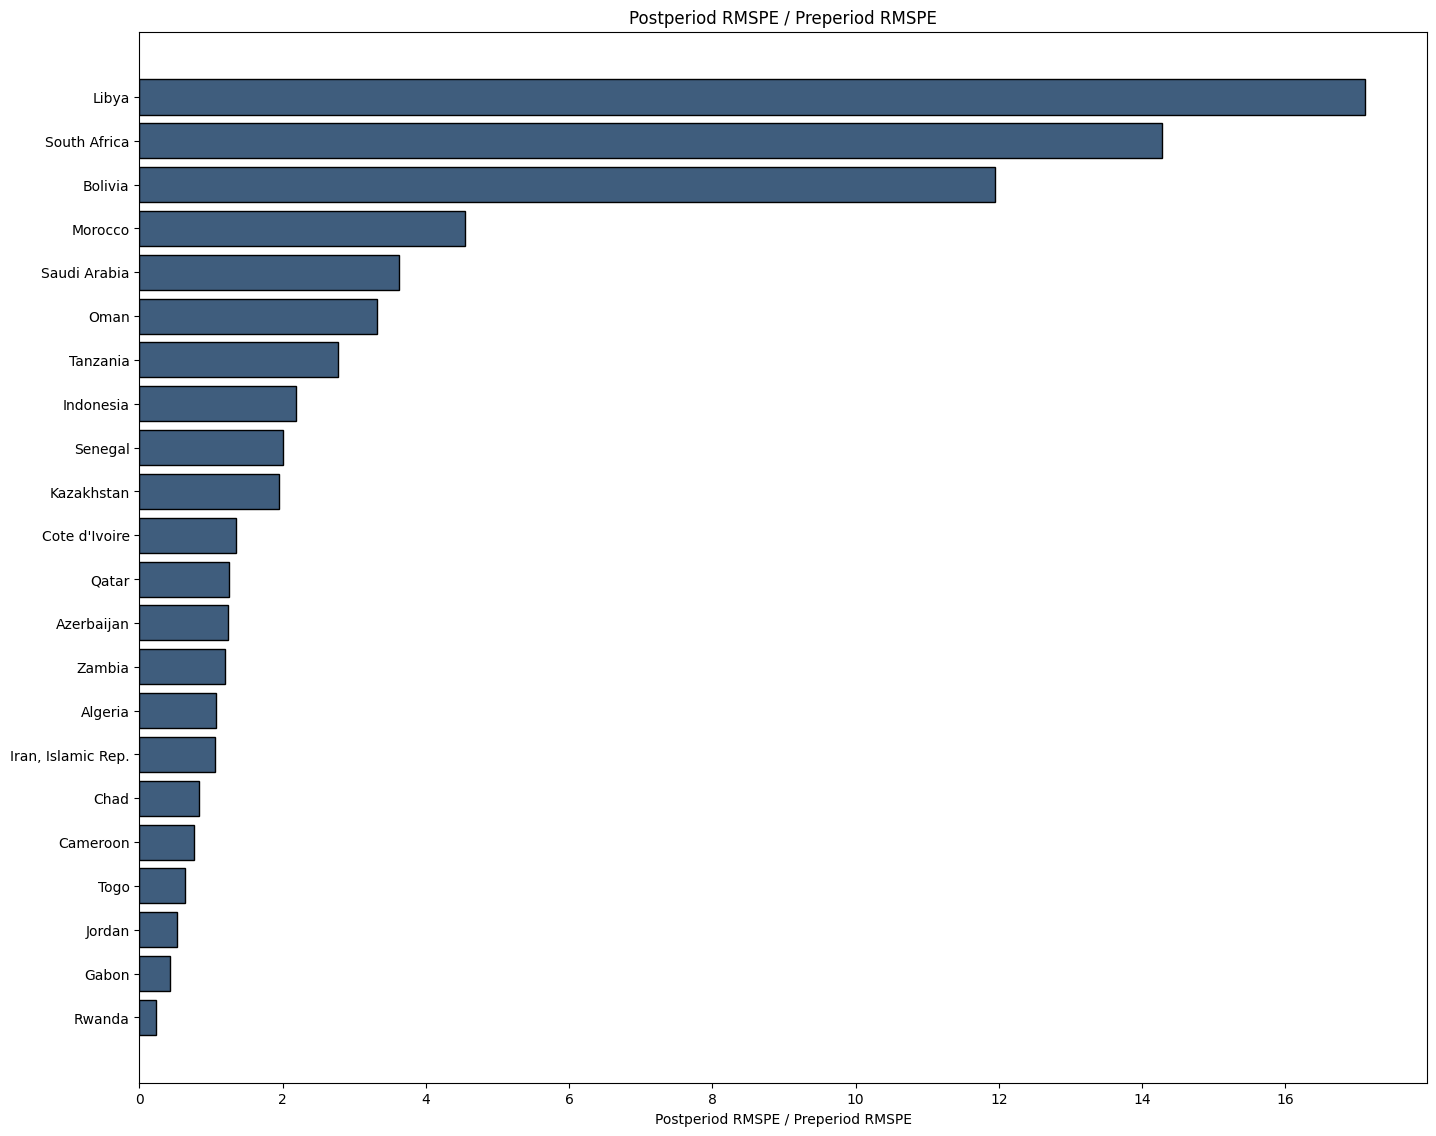

In [12]:
sc.plot(['rmspe ratio'])

In [13]:
dsc_no_pen = DiffSynth (data, "GDP per capita (constant 2015 US$)", "Country Name", "Time", 2011, "Libya", n_optim = 30, random_seed = 0)

(11,)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)


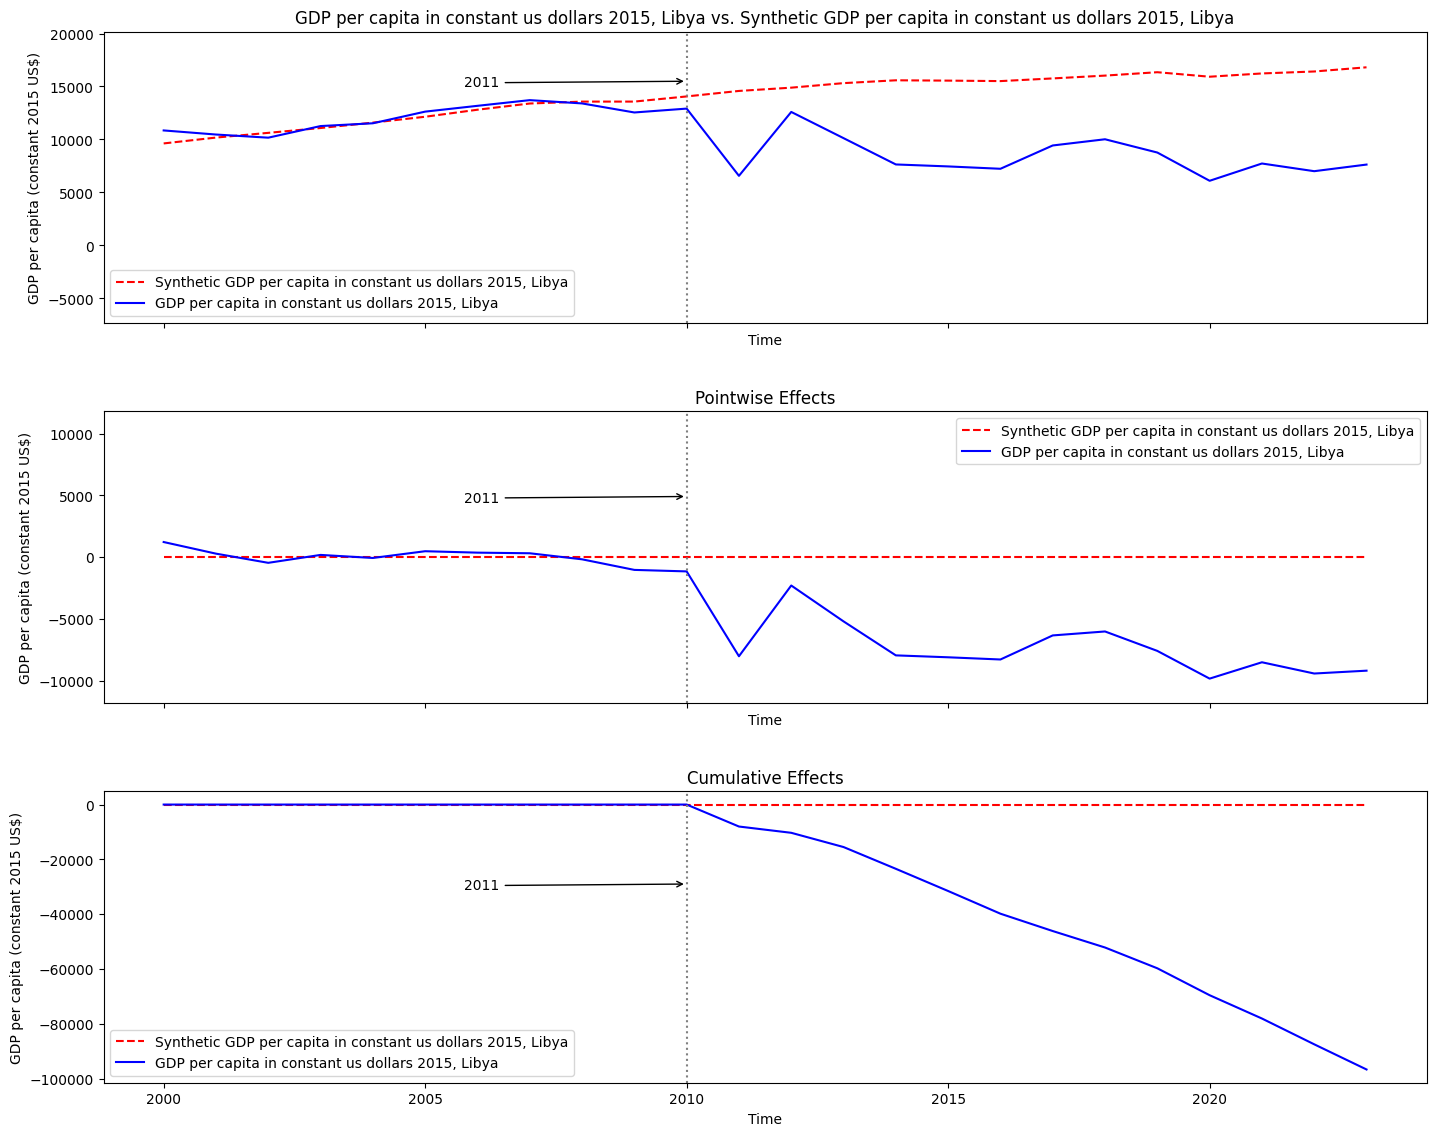

In [14]:
dsc_no_pen.plot(["original", "pointwise", "cumulative"], 
        treated_label="GDP per capita in constant us dollars 2015, Libya", 
        synth_label="Synthetic GDP per capita in constant us dollars 2015, Libya", 
        treatment_label="2011")

In [15]:
dsc_no_pen.original_data.weight_df

,Weight
Kazakhstan,1.0


In [16]:
dsc_no_pen.original_data.rmspe_df

,unit,pre_rmspe,post_rmspe,post/pre
0,Libya,654.16547,7688.350515,11.752914


In [17]:
dsc_no_pen.original_data.comparison_df

,Libya,Synthetic Libya,WMAPE,Importance
Population growth (annual %) [SP.POP.GROW],0.04,0.10,1.22,0.11
Asylum-seekers by country or territory of origin [SM.POP.ASYS.EO],2.70,1.00,15.82,0.04
Access to electricity (% of population) [EG.ELC.ACCS.ZS],-1.79,0.04,9.62,0.03
External balance on goods and services (% of GDP) [NE.RSB.GNFS.ZS],1.66,0.68,20.96,0.42
Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS],3.47,-1.24,8.13,0.00
GDP per capita (constant 2015 US$),96.44,17.52,5358.29,0.00
Trade (% of GDP) [NE.TRD.GNFS.ZS],5.28,-3.16,4.70,0.00
Merchandise trade (% of GDP) [TG.VAL.TOTL.GD.ZS],6.78,-1.42,14.61,0.00
"Birth rate, crude (per 1,000 people) [SP.DYN.CBRT.IN]",0.19,0.68,3.70,0.42
"Death rate, crude (per 1,000 people) [SP.DYN.CDRT.IN]",-0.01,-0.17,5.37,0.00


(11,)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)
(1, 11)


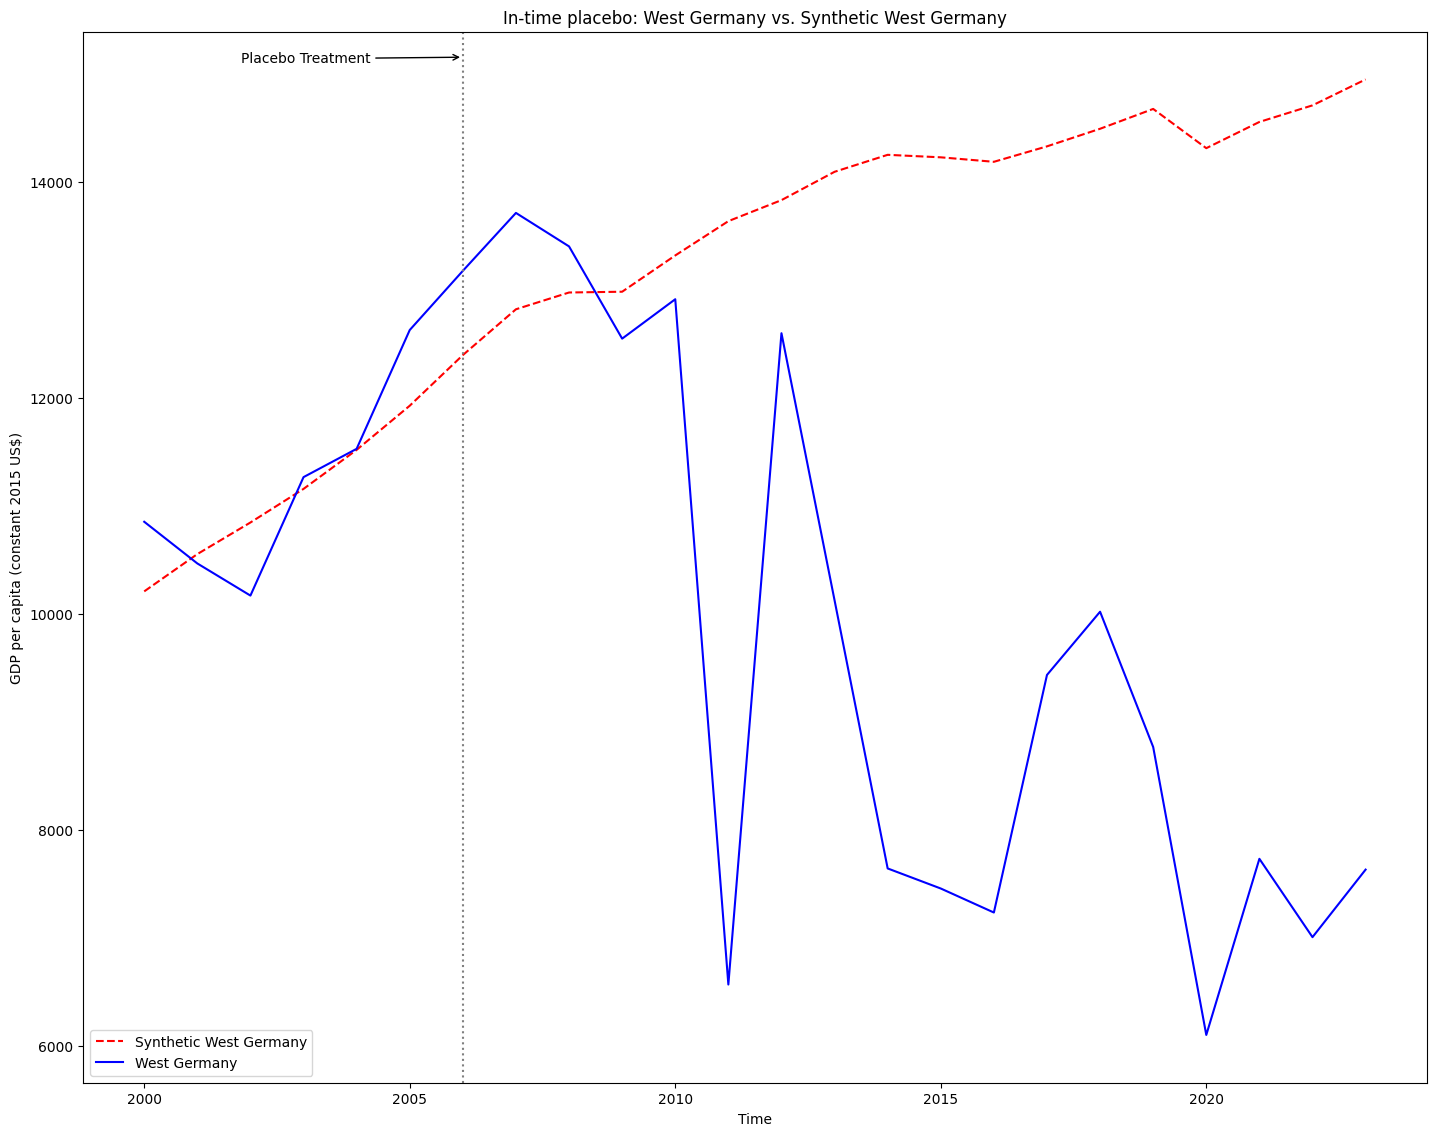

In [18]:
dsc_no_pen.in_time_placebo(2006, n_optim=10)

#Visualize
dsc_no_pen.plot(['in-time placebo'], 
            treated_label="West Germany",
            synth_label="Synthetic West Germany")